# **Liquid Crystal RDSOC Example**
### Calculating momentum splitting of circularly polarized modes in a liquid crystal DBR cavity. Powered by [$S^4$](https://web.stanford.edu/group/fan/S4/). Credit due to Victor Liu (Fan Group, Stanford Electrical Engineering Department, 2012).

#### This notebook version written by Ezra Bader (Menon Group / LaNMP, CCNY, May 2026) with help from Dr. Claude (Anthropic).

<div style="display: flex; justify-content: left; align-items: center; gap: 20px;">
<img src="https://web.stanford.edu/group/fan/S4/_images/schem_640.png" alt="schematic" width="400" style="border: 5px solid maroon;">

<img src="https://journals.aps.org/prapplied/article/10.1103/PhysRevApplied.17.014041/figures/1/medium" alt="rdsoc" width="340" style="border: 5px solid maroon;">
</div>

<span style="font-size:30px;">**Workflow:**</span>

<span style="font-size:20px;">**1.** Imports</span>

<span style="font-size:20px;">**2.** Lattice & layers</span>

<span style="font-size:20px;">**3.** Configure parameters</span>

<span style="font-size:20px;">**4.** Verify/plot unit cell, refractive index</span>

<span style="font-size:20px;">**5.** Core S4 functions</span>

<span style="font-size:20px;">**6.** Convergence and spot tests</span>

<span style="font-size:20px;">**7.** Run studies or load data</span>

<span style="font-size:17px;"> &emsp; 7.0.1 — Quick checks, run study 0 (reflection)</span>

<span style="font-size:17px;"> &emsp; 7.1.1 — Run study 1 (E vs. k)</span>

<span style="font-size:17px;"> &emsp; 7.2.1 — Run study 2 (kx, ky)</span>

<span style="font-size:17px;"> &emsp; 7.3.1 — Run study 3 (mode calculation)</span>

<span style="font-size:20px;">**8.** Plotting</span>

<span style="font-size:20px;">**9.** Examples</span>

<span style="font-size:17px;"> &emsp; 9.1 — Liquid Crystal RDSOC</span>

### Under construction --

<span style="font-size:20px;">**??.** GUI

<span style="font-size:20px;">**??.** Polarization vortex analysis


-------------------
# **Requirements**
### All standard python libraries will import automatically. If a library is not found, you probably haven't installed it in your environment. If you are using a conda environment, for example, and \<library-name\> is not found, you'll run the following in your command line:

```bash
conda activate <your-env-name>
conda install <library-name>
```

### Slightly more complicated is S4, which should be built from the source code. Unix-like environment and C++ compiler required—on Windows, you'll have to use something like WSL (Windows Subsystem for Linux). Then in the terminal:

```bash
cd ~/your-project-folder
git clone https://github.com/victorliu/S4.git
```

### Nothing else is technically required, but [the authors recommend](https://web.stanford.edu/group/fan/S4/install.html) certain additional packages. Once you've flagged these in your Makefile:

```bash
make lib
make S4_pyext
```

# **1. Imports**

In [287]:
import rcwa_utils as ru     # NOTE: Imports all the necessary helper functions to run this notebook.
from rcwa_utils import *    
import S4                   # NOTE: Your python environment must have a valid S4 installation
import numpy as np
import pandas as pd
from abc import ABC, abstractmethod
import threading
import time, warnings, itertools
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
from scipy.interpolate import interp1d, griddata
from pathlib import Path
from joblib import Parallel, delayed
import re as _re
from datetime import datetime as _dt
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
from scipy.interpolate import griddata
import tkinter as tk
from tkinter import filedialog
import tempfile
import os
import shutil
import importlib
from dataclasses import dataclass, field
importlib.reload(ru)

MATERIALS = ru.load_material_library()

Material library loaded. Currently supported materials:
Air, Si, SiO2, TiO2, SiN, CrSBr, MoOCl2, ReS2, LC


# **Layers**

For each layer specify a <span style="color:#9CDCFE">**MATERIAL**</span> and <span style="color:#9CDCFE">**THICKNESS**</span> (nm). Lattice constant will be set in the next cell.

Optional arguments:

<span style="color:#9CDCFE">**PATTERN**</span>  — Currently supported: 'hole', 'pillar', 'cuboids'.

<span style="color:#9CDCFE">**ROT (°)**</span>      — Rotates permittivity tensor $\bm{\epsilon_{ij}}$ about $\bm{\hat{z}}$. 

<span style="color:#9CDCFE">**TILT (°)**</span>     — Tilts $\bm{\epsilon_{ij}}$ towards $\bm{\hat{z}}$.
```python
# EXAMPALE CALLS: 

MY_LAYERS1 = [
    ru.Layer('Air',    500,    pattern=None),
    ru.Layer('SiO2',   50,     pattern='hole', ff=0.5),
    ru.Layer('CrSBr',  70,     pattern='hole', ff=0.5, layer_rot=45),
    ru.Layer('Air',    500,    pattern=None)
]

MY_LAYERS2 = [
    ru.Layer('Air',    500,    pattern=None),
    ru.Layer('ReS2',   90,     pattern='cuboids', w0=250, alpha=0.6),
    ru.Layer('Air',    500,    pattern=None)
]
```

In [276]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║       LAYERS  (top to bottom; pick material, thickness in nm)            ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# NOTE: Stack is built top down, where the first layer starts at z=0 and ends at z=|layer_thickness|.
#       The "transmission" side will be the LAST layer in the following list.
#       Since RCWA is all plane waves, the actual orientation of your stack
#       shouldn't matter UNLESS your materials break reciprocity! Then you can no longer safely
#       exchange source & detector.

MY_LAYERS = [
    ru.Layer('Air',    500,    pattern=None),
    *ru.DBR(5, centerlam_nm=550, orientation='top'),
    ru.Layer('LC', 3450),
    *ru.DBR(5, centerlam_nm=550, orientation='bottom'),
    ru.Layer('Air',    500,    pattern=None)
]

ru.check_layers(layers=MY_LAYERS)

layer   material    thickness (nm)        pattern                 rot (°)     tilt (°)          
------------------------------------------------------------------------------------------------
0       Air         500.00                None                    0           0                 
1       SiO2        94.18                 None                    0           0                 
2       TiO2        62.50                 None                    0           0                 
3       SiO2        94.18                 None                    0           0                 
4       TiO2        62.50                 None                    0           0                 
5       SiO2        94.18                 None                    0           0                 
6       TiO2        62.50                 None                    0           0                 
7       SiO2        94.18                 None                    0           0                 
8       TiO2        62.50     

# **3. Configure Parameters**

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                          SWEEP CONFIG.                                   ║
# ╚══════════════════════════════════════════════════════════════════════════╝

confLC = ru.RCWAConfig(
    layers = MY_LAYERS,
    lattice_const = 500.0,
    lam_start = 500.0,
    lam_stop = 650.0,
    lam_step = 0.5,
    n_basis = 49,
    n_jobs = 8,
    global_rot = 0,          # Global index tensor rotation around ẑ
    global_tilt = 0,           # Global index tensor tilt, pivots ẑ about origin
    global_tilt_azim = 180,    # Target azimuthal angle for global tilt, defaults towards +x̂ 
    # save_to='default',
    save_to = '/Users/ezra/Desktop/LaNMP/python_scripts/RCWA/globalVersion/rcwa_output/LCexample',

    # Defining study 1, E vs. k
    study1 = ru.Study1Config(
        elev_max = 45.0,
        elev_n = 90,
        azim_vals = [0.0, 90.0]
    ),

    # Defining study 2, kx vs. ky
    study2 = ru.Study2Config(
        elev_max = 40.0,
        elev_n = 40,
        azim_n_max = 180,
        azim_n_min = 45
    )
)

confLC.verify_config()

layer   material    thickness (nm)        pattern                 rot (°)     tilt (°)          
------------------------------------------------------------------------------------------------
0       Air         500.00                None                    0           0.0 @ azim 180°   
1       SiO2        94.18                 None                    0           0.0 @ azim 180°   
2       TiO2        62.50                 None                    0           0.0 @ azim 180°   
3       SiO2        94.18                 None                    0           0.0 @ azim 180°   
4       TiO2        62.50                 None                    0           0.0 @ azim 180°   
5       SiO2        94.18                 None                    0           0.0 @ azim 180°   
6       TiO2        62.50                 None                    0           0.0 @ azim 180°   
7       SiO2        94.18                 None                    0           0.0 @ azim 180°   
8       TiO2        62.50     

# **4. Unit Cell and Refractive Index Plots**

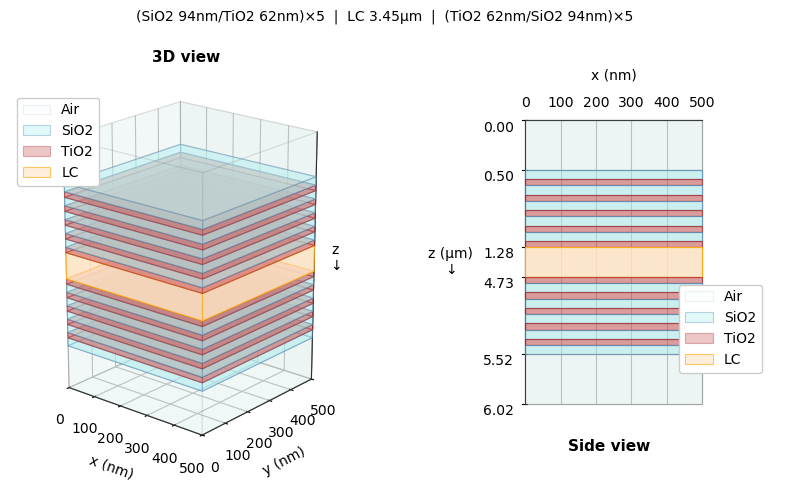

In [280]:
importlib.reload(ru)
MATERIAL_COLORS = ru.get_material_colors()

# indexplot = ru.plot_refractive_index(conf,layers=None,materials=None,lam_min=None,lam_max=None,n_pts=600)
# indexplot = ru.plot_refractive_index(conf, lam_min = 500, lam_max= 600)
unitcellplot = ru.plot_unit_cell(confLC, save_fig = False)

# **5. Core S4 Functions**

In [281]:
importlib.reload(ru) # For development, reloads source code
from rcwa_utils import (
    build_simulation, 
    update_simulation_materials, 
    sp_basis, 
    get_z_sample, 
    get_jones_matrices, 
    jones_to_circular, 
    compute_observables
)

# **6. Convergence tests**

### **6.1** Test definitions

In [282]:
importlib.reload(ru) # For development, reloads source code
from rcwa_utils import (
    convergence_test,
    convergence_test_phase,
    scan_wavelengths,
    verify_energy_conservation
)

### **6.2** Run tests

In [283]:
convergence_test(confLC, basis_vals=(1, 4, 25, 49))
convergence_test_phase(confLC, basis_vals=(1, 4, 25, 49))
scan_wavelengths(confLC)
verify_energy_conservation(confLC)

%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--
Convergence test: λ=550 nm  elev=5.0°  azim=0°  rot=0°  tilt=0°
Stack: Layer(Air, 500.00nm) | Layer(SiO2, 94.18nm) | Layer(TiO2, 62.50nm) | Layer(SiO2, 94.18nm) | Layer(TiO2, 62.50nm) | Layer(SiO2, 94.18nm) | Layer(TiO2, 62.50nm) | Layer(SiO2, 94.18nm) | Layer(TiO2, 62.50nm) | Layer(SiO2, 94.18nm) | Layer(TiO2, 62.50nm) | Layer(LC, 3450.00nm) | Layer(TiO2, 62.50nm) | Layer(SiO2, 94.18nm) | Layer(TiO2, 62.50nm) | Layer(SiO2, 94.18nm) | Layer(TiO2, 62.50nm) | Layer(SiO2, 94.18nm) | Layer(TiO2, 62.50nm) | Layer(SiO2, 94.18nm) | Layer(TiO2, 62.50nm) | Layer(SiO2, 94.18nm) | Layer(Air, 500.00nm)
|   NumBasis        T_ss        T_pp     |dT_ss|    time(ms)
|          1     0.08550     0.00625         nan         2.0
|          4     0.08550     0.00625     0.00000         1.4
|         25     0.08550     0.00625     0.00000       147.3
|         49     0.08550     0.00625     0.00000       619.9
%--%--

# **7. Run Studies or Load Data**

### **7.0.1 Quick Tests & Study 0 (reflection)**

In [ ]:
# importlib.reload(ru)
quick_test1 = ru.quick_test_study1(confLC)


Study 1: 8 pairs  |  8 workers
  P=500 nm  |  Air 500nm  |  SiO2 94nm  |  TiO2 62nm  |  SiO2 94nm  |  TiO2 62nm  |  SiO2 94nm  |  TiO2 62nm  |  SiO2 94nm  |  TiO2 62nm  |  SiO2 94nm  |  TiO2 62nm  |  SiO2 94nm  |  TiO2 62nm  |  LC 3450000nm  |  TiO2 62nm  |  SiO2 94nm  |  TiO2 62nm  |  SiO2 94nm  |  TiO2 62nm  |  SiO2 94nm  |  TiO2 62nm  |  SiO2 94nm  |  TiO2 62nm  |  SiO2 94nm  |  TiO2 62nm  |  SiO2 94nm  |  Air 500nm
  Study 1 [1/8  12%]  0.1 min elapsed,  ETC: 0.8 min  (7.2 s/task)
  Study 1 [2/8  25%]  0.1 min elapsed,  ETC: 0.4 min  (3.6 s/task)
  Study 1 [3/8  38%]  0.1 min elapsed,  ETC: 0.2 min  (2.4 s/task)
  Study 1 [4/8  50%]  0.1 min elapsed,  ETC: 0.1 min  (1.8 s/task)
  Study 1 [5/8  62%]  0.1 min elapsed,  ETC: 0.1 min  (1.4 s/task)
  Study 1 [6/8  75%]  0.1 min elapsed,  ETC: 0.0 min  (1.2 s/task)
  Study 1 [7/8  88%]  0.1 min elapsed,  ETC: 0.0 min  (1.0 s/task)
  Study 1 [8/8  100%]  0.1 min elapsed,  ETC: 0.0 min  (0.9 s/task)
%--%--%--%--%--%--%--%--%--%--%--%--%--%

### **7.1.1 Study 1 (E vs. k)**

In [284]:
df_study1_LC_0          = run_study1(dataclasses.replace(confLC, global_tilt = 0, global_tilt_azim = 180), print_every=32)
# df_study1_LC_10         = run_study1(dataclasses.replace(confLC, global_tilt = 10), print_every=32)
df_study1_LC_30         = run_study1(dataclasses.replace(confLC, global_tilt = 30, global_tilt_azim=180), print_every=32)
# df_study1_LC_5115       = run_study1(dataclasses.replace(confLC, global_tilt = 51.15), print_every=32)
df_study1_LC_60         = run_study1(dataclasses.replace(confLC, global_tilt = 60, global_tilt_azim=180), print_every=32)
# df_study1_LC_6515       = run_study1(dataclasses.replace(confLC, global_tilt = 65.15), print_every=32)
# df_study1_LC_80         = run_study1(dataclasses.replace(confLC, global_tilt = 80), print_every=32)
df_study1_LC_90         = run_study1(dataclasses.replace(confLC, global_tilt = 90, global_tilt_azim=180), print_every=32)

Study 1: 180 pairs  |  8 workers
  P=500 nm  |  Air 500nm  |  SiO2 94nm  |  TiO2 62nm  |  SiO2 94nm  |  TiO2 62nm  |  SiO2 94nm  |  TiO2 62nm  |  SiO2 94nm  |  TiO2 62nm  |  SiO2 94nm  |  TiO2 62nm  |  LC 3450nm  |  TiO2 62nm  |  SiO2 94nm  |  TiO2 62nm  |  SiO2 94nm  |  TiO2 62nm  |  SiO2 94nm  |  TiO2 62nm  |  SiO2 94nm  |  TiO2 62nm  |  SiO2 94nm  |  Air 500nm
  Study 1 [32/180  18%]  0.1 min elapsed,  ETC: 0.5 min  (0.2 s/task)
  Study 1 [64/180  36%]  0.1 min elapsed,  ETC: 0.3 min  (0.1 s/task)
  Study 1 [96/180  53%]  0.2 min elapsed,  ETC: 0.2 min  (0.1 s/task)
  Study 1 [128/180  71%]  0.2 min elapsed,  ETC: 0.1 min  (0.1 s/task)
  Study 1 [160/180  89%]  0.3 min elapsed,  ETC: 0.0 min  (0.1 s/task)
  Study 1 [180/180  100%]  0.3 min elapsed,  ETC: 0.0 min  (0.1 s/task)
%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--
Study 1 done in 0.3 min
/Users/ezra/Desktop/LaNMP/python_scripts/RCWA/globalVersion/rcwa_output/LCexample
|
|
V
Config 

### **7.2.1 Study 2 (kx vs. ky)**

In [ ]:
# df_study2 = run_study2(conf)

### **7.3.1 Study 3 (Modes)**

In [248]:
# df_study3 = run_study3(conf)
importlib.reload(ru)

<module 'rcwa_utils' from '/Users/ezra/gitprojects/rcwa-phc/rcwa_utils.py'>

### **7.4 Load Saved Data**

```python
ex_conf_loaded = ru.RCWAConfig.load('/Your_path_here.json')
```

In [247]:
# ── Load saved data with config ────────────────────────────────────────────────────────────
# NOTE: As of 2026 May 12, every study that gets run will automatically save with
# a config file of the same filename and extension .json. This config file
# contains all study parameters and must be recalled to plot the data.

df_load, conf_load = ru.load_study('/Users/ezra/Desktop/LaNMP/python_scripts/RCWA/globalVersion/rcwa_output/study1_A500nm_SiO2-50nm-hole-ff0.5_CrSBr-70nm-hole-ff0.5_SiO2-100nm_rot00_nb25.json')
conf_load.verify_config()


Loaded 128 rows  |  study1_A500nm_SiO2-50nm-hole-ff0.5_CrSBr-70nm-hole-ff0.5_SiO2-100nm_rot00_nb25.csv



TypeError: unsupported format string passed to NoneType.__format__

# **8. Plotting**

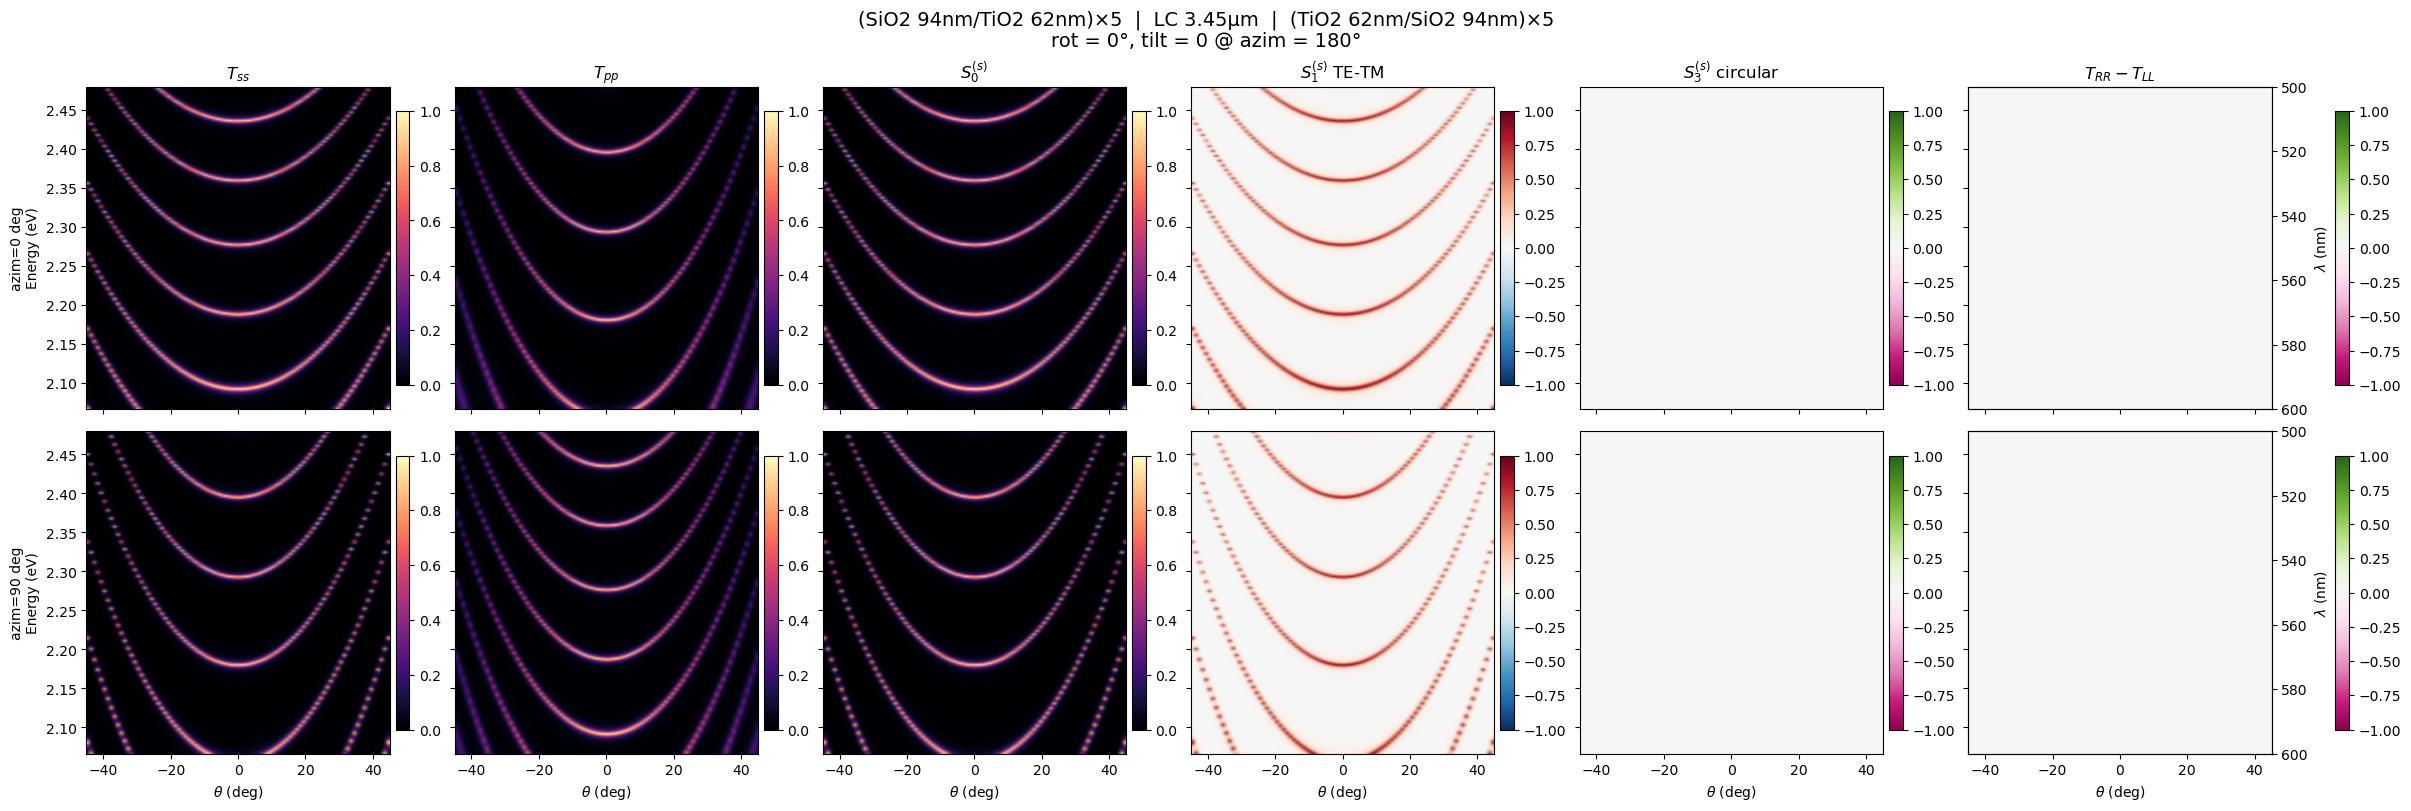

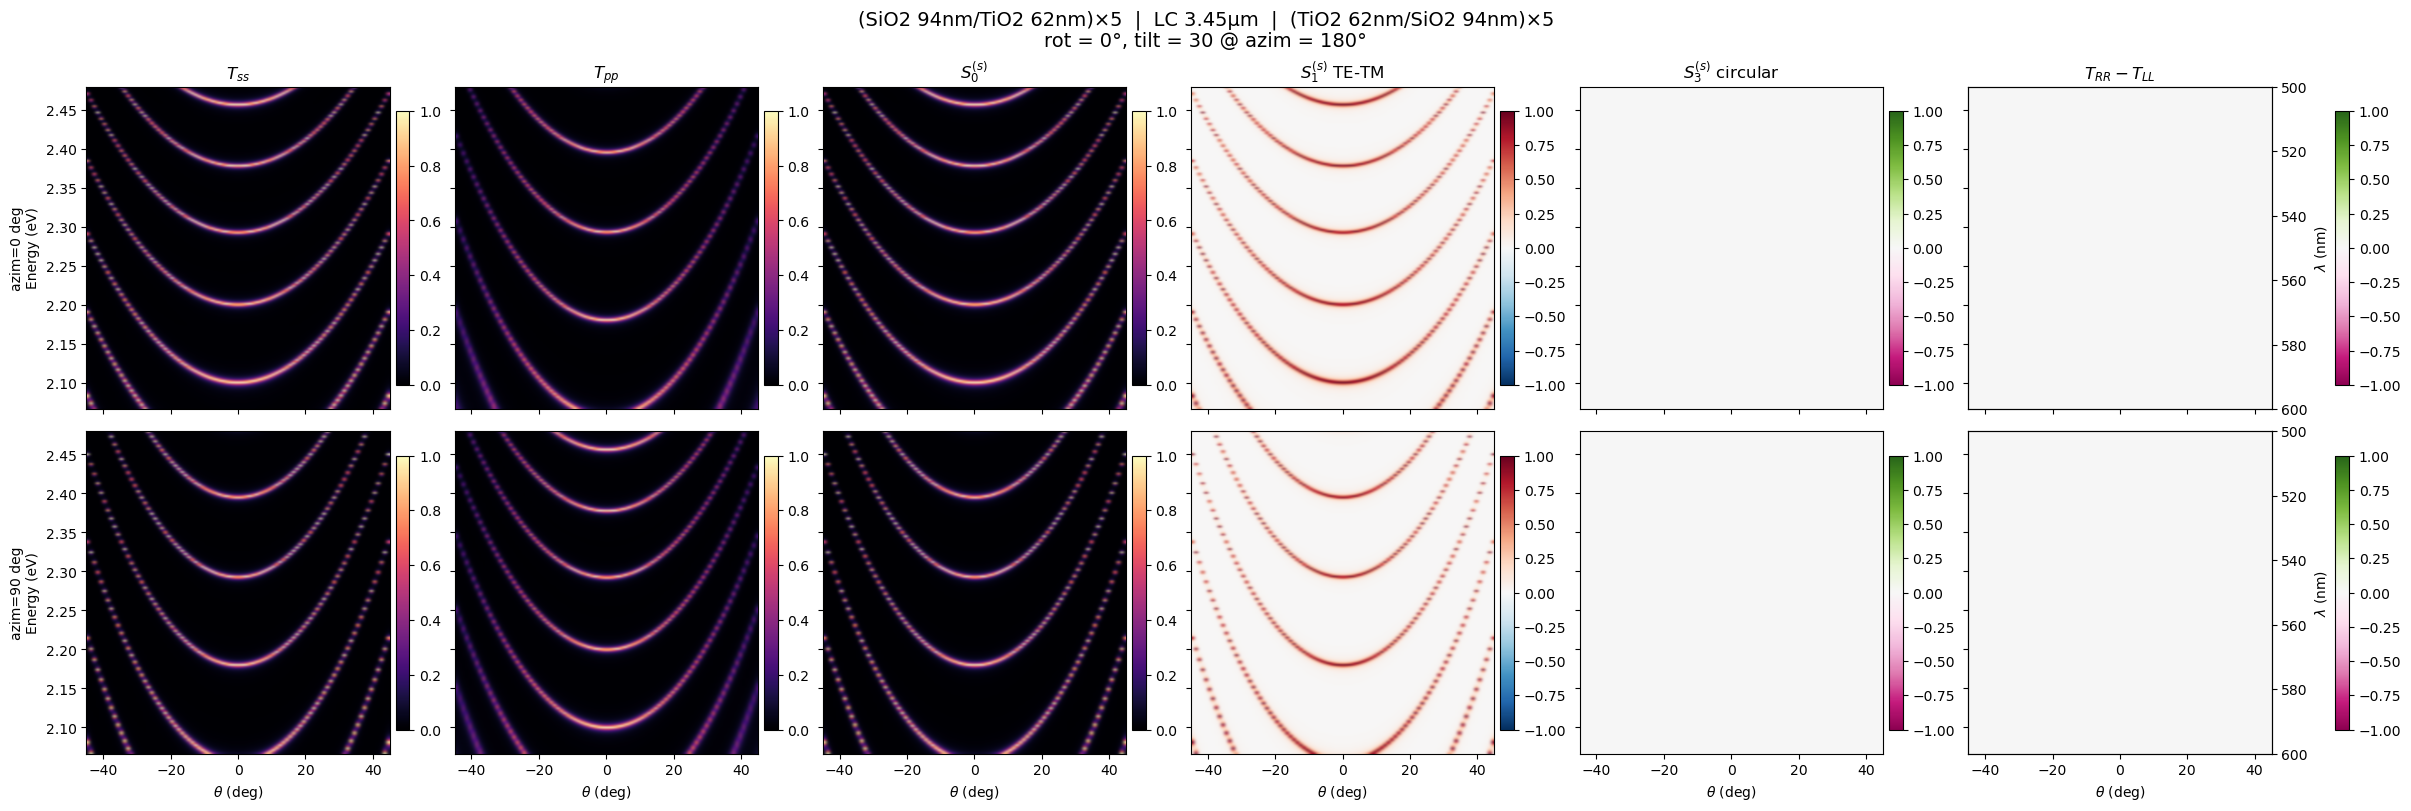

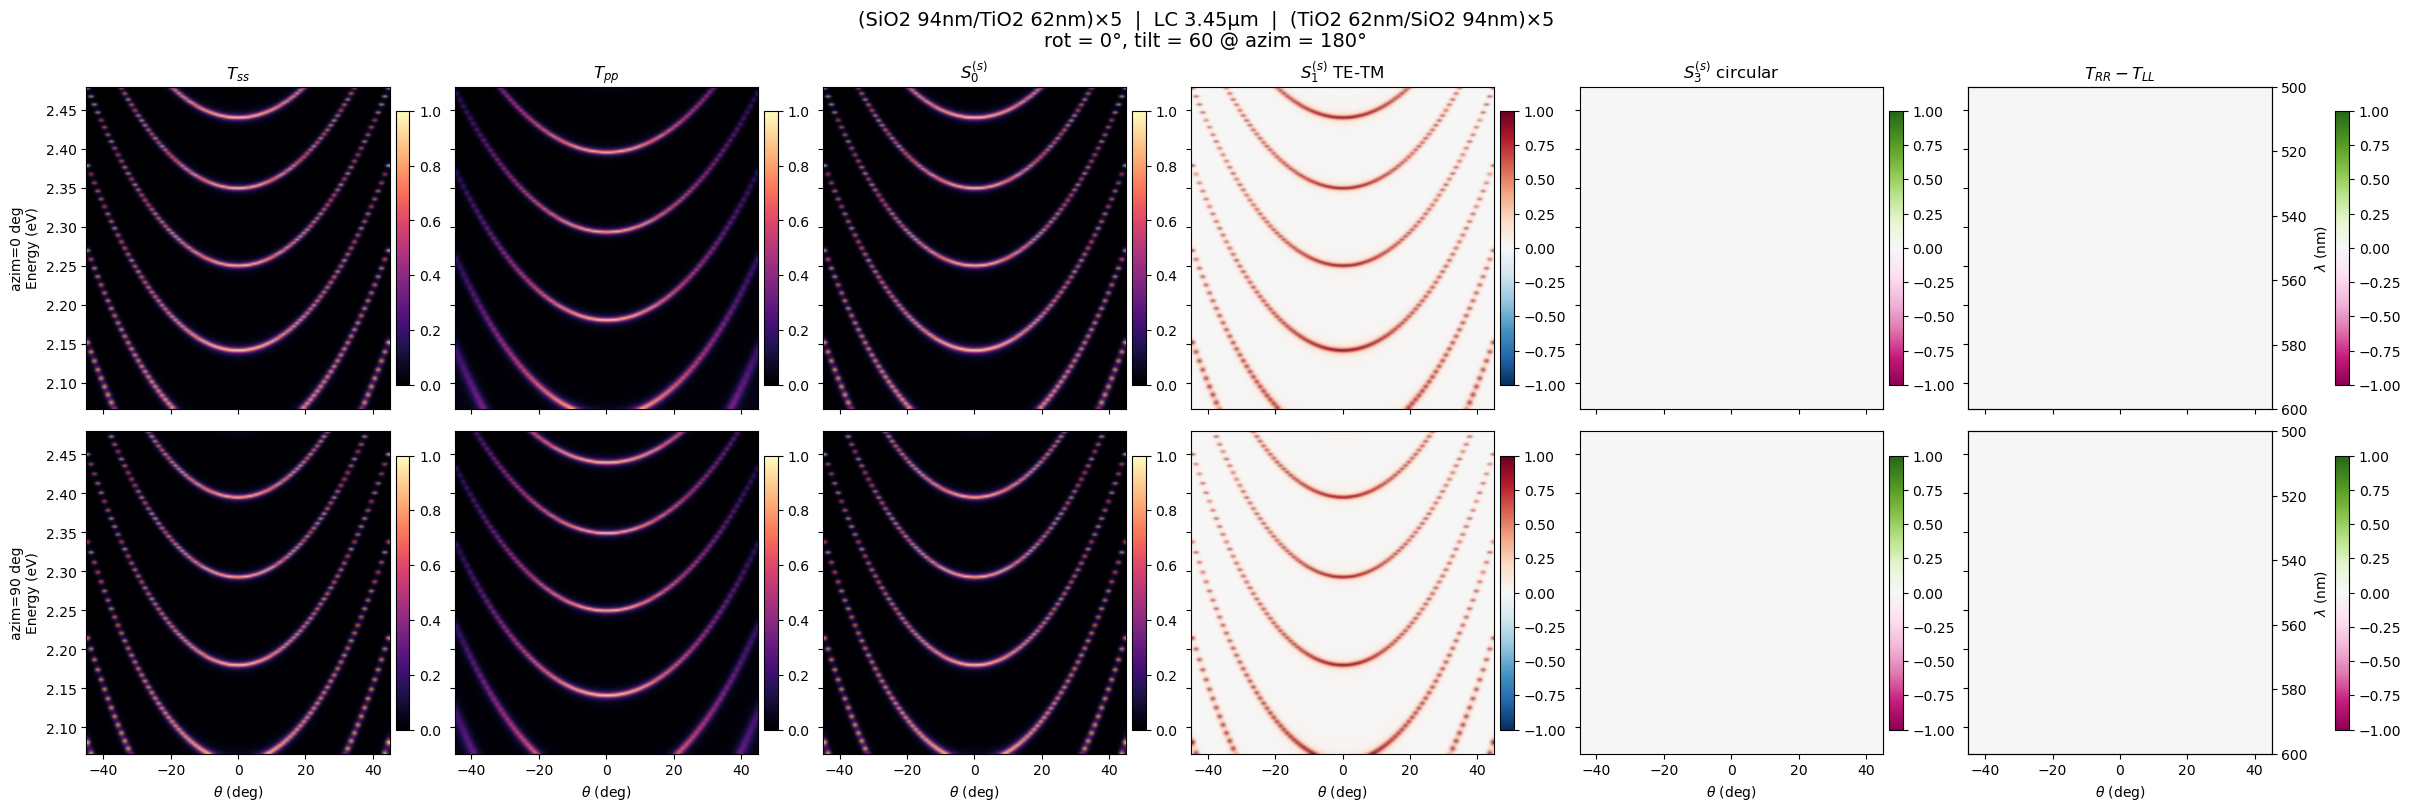

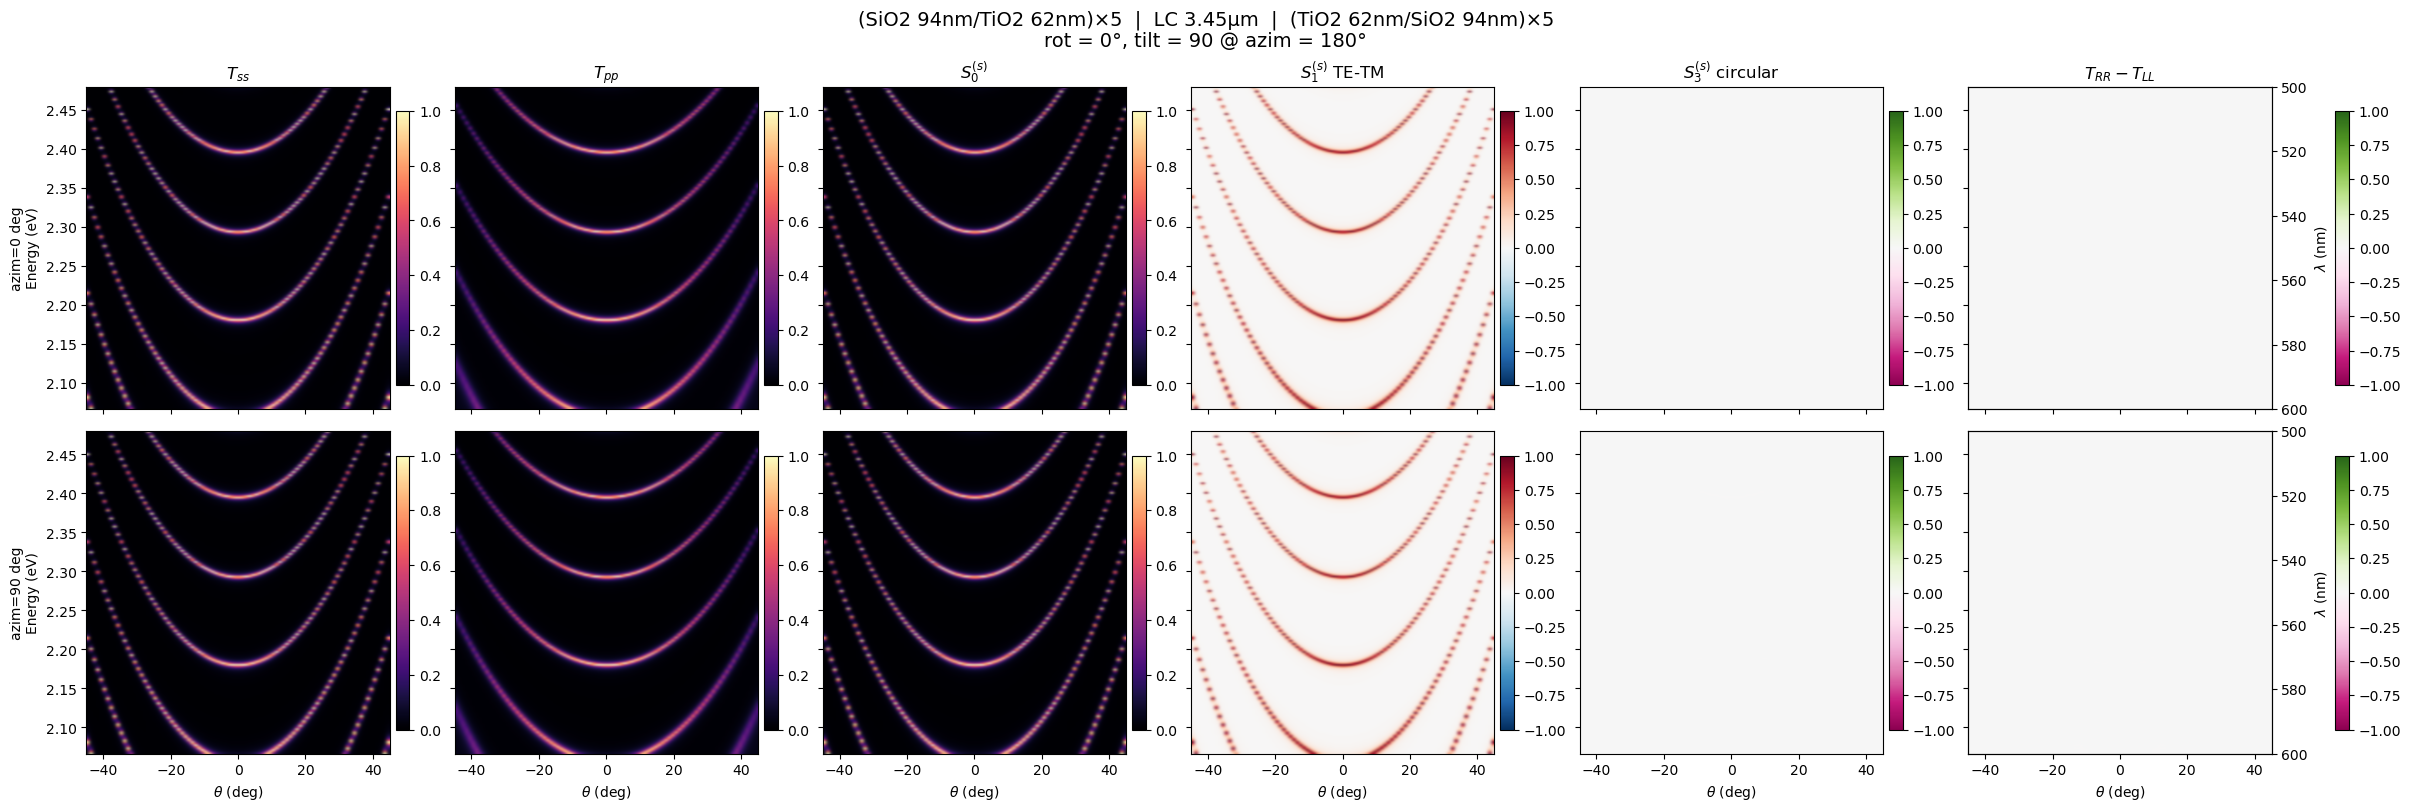

In [285]:
# plot_study1DBR = ru.plot_study1(df_study1_DBR, confLC, tilt_deg=30)
plot_df_study1_LC_0          = ru.plot_study1(df_study1_LC_0,     dataclasses.replace(confLC,       global_tilt = 0, global_tilt_azim = 180       ),      tilt_deg= 0, tilt_azim_deg=180  )
# plot_df_study1_LC_10         = ru.plot_study1(df_study1_LC_10,     dataclasses.replace(confLC,      global_tilt = 10      ),      tilt_deg= 10         )
plot_df_study1_LC_30         = ru.plot_study1(df_study1_LC_30,     dataclasses.replace(confLC,      global_tilt = 30, global_tilt_azim = 180      ),    tilt_deg= 30, tilt_azim_deg=180         )
# plot_df_study1_LC_5115       = ru.plot_study1(df_study1_LC_5115,     dataclasses.replace(confLC,    global_tilt = 51.15   ),      tilt_deg= 51.15      )
plot_df_study1_LC_60         = ru.plot_study1(df_study1_LC_60,     dataclasses.replace(confLC,      global_tilt = 60, global_tilt_azim = 180      ),    tilt_deg= 60, tilt_azim_deg=180         )
# plot_df_study1_LC_6515       = ru.plot_study1(df_study1_LC_6515,     dataclasses.replace(confLC,    global_tilt = 65.15   ),      tilt_deg= 65.15      )
# plot_df_study1_LC_80         = ru.plot_study1(df_study1_LC_80,     dataclasses.replace(confLC,      global_tilt = 80      ),      tilt_deg= 80         )
plot_df_study1_LC_90         = ru.plot_study1(df_study1_LC_90,     dataclasses.replace(confLC,      global_tilt = 90, global_tilt_azim = 180      ),      tilt_deg= 90, tilt_azim_deg=180         )

## Appendix

### Geometry options

| GEOMETRY | Description |
|---|---|
| `'pillar'` | Single square pillar in air background |
| `'hole'` | Single square air hole in slab |
| `'cuboids'` | Two asymmetric square pillars (diagonal arrangement) |

### Material notes
- **CrSBr**: dispersive anisotropic tensor from interpolated n,k data. `PHIZ_VALS` sweeps the b-axis rotation angle.
- **ReS2**: non-dispersive birefringent dielectric. `EPS0` and `DELTA_EPS` set the permittivities directly.

### Key conventions
- s-polarisation = ⊥ plane of incidence (TE in COMSOL, = ŷ at azim=0°, normal incidence)
- p-polarisation = ∥ plane of incidence (TM in COMSOL)
- Circular: R = (s+ip)/√2, L = (s−ip)/√2
- CD = T_RR − T_LL (positive = more right-circular transmitted)
- S3 > 0: right-elliptical output for s-pol input

### S4 API reference
| Call | Purpose |
|---|---|
| `S.SetFrequency(1/lam)` | Set wavelength (lam in same units as lattice) |
| `S.SetMaterial(Name, Epsilon)` | Update material (cheap, reuses geometry) |
| `S.SetExcitationPlanewave(...)` | Set incident field |
| `S.GetFieldsOnGridNumpy(z, (N,N))` | Fast field grid → shape (N,N,3) |
| `S.GetPowerFlux(Layer, zOffset)` | T/R power flux |
| `S.GetBasisSet()` | List of (i,j) G-vectors |
